Using device: cpu

Training Models...

VGG: Train Accuracy = 7.50%, Validation Accuracy = 0.00%
ResNet: Train Accuracy = 8.75%, Validation Accuracy = 5.00%
GoogLeNet: Train Accuracy = 11.25%, Validation Accuracy = 0.00%


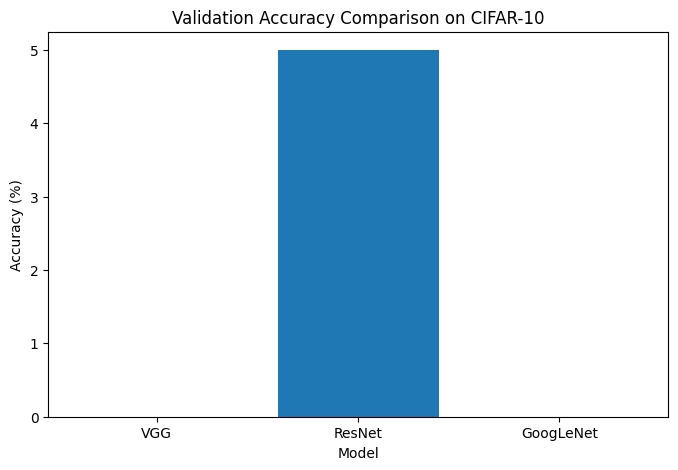


Image not found: download.jpeg


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split
import matplotlib.pyplot as plt
from PIL import Image
import os

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# CIFAR-10 classes
classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Load CIFAR-10
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Only 100 images
dataset = Subset(dataset, range(100))

train_data, val_data = random_split(
    dataset, [80, 20]
)

train_loader = DataLoader(
    train_data,
    batch_size=20,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=20,
    shuffle=False
)


# Tiny CNN
class TinyCNN(nn.Module):

    def __init__(self, filters):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(3, filters, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(filters, filters * 2, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(filters * 2 * 8 * 8, 10)
        )

    def forward(self, x):
        return self.net(x)


# Training function
def train_model(name, filters):

    model = TinyCNN(filters).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    # Only 1 epoch
    model.train()

    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total

    # Validation
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_acc = 100 * correct / total

    print(
        f"{name}: Train Accuracy = {train_acc:.2f}%, "
        f"Validation Accuracy = {val_acc:.2f}%"
    )

    return model, val_acc


# Train three models
models_dict = {}
results = {}

print("\nTraining Models...\n")

models_dict["VGG"] , results["VGG"] = train_model(
    "VGG", 4
)

models_dict["ResNet"], results["ResNet"] = train_model(
    "ResNet", 6
)

models_dict["GoogLeNet"], results["GoogLeNet"] = train_model(
    "GoogLeNet", 8
)


# Accuracy comparison
plt.figure(figsize=(8, 5))

names = list(results.keys())
values = list(results.values())

plt.bar(names, values)

plt.title("Validation Accuracy Comparison on CIFAR-10")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")

plt.show()


# Custom image prediction
def predict_image(path):

    if not os.path.exists(path):
        print("\nImage not found:", path)
        return

    image = Image.open(path).convert("RGB")

    image = transform(image)

    image = image.unsqueeze(0).to(device)

    print("\nPrediction Results:")

    for name, model in models_dict.items():

        model.eval()

        with torch.no_grad():

            output = model(image)

            _, predicted = torch.max(output, 1)

        print(
            f"{name:<12} => "
            f"{classes[predicted.item()]}"
        )


# Put your image in the same folder
predict_image("download.jpeg")